In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [7]:
raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  22 non-null     str  
 1   Message  22 non-null     str  
 2   Status   22 non-null     str  
dtypes: str(3)
memory usage: 660.0 bytes


In [8]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [10]:
fs01_dec_value=[]
fs02_dec_value=[]

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')
    if len(e0x_aux)>0:
        fs01=(e0x_aux[aux:aux+18])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if len(e0x_aux)>0:
        fs02=e0x_aux[aux:aux+18]
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
print('El Ncode en decimal es:')
print(fs01_dec_value,fs01_count)

El Ncode en decimal es:
[] 0


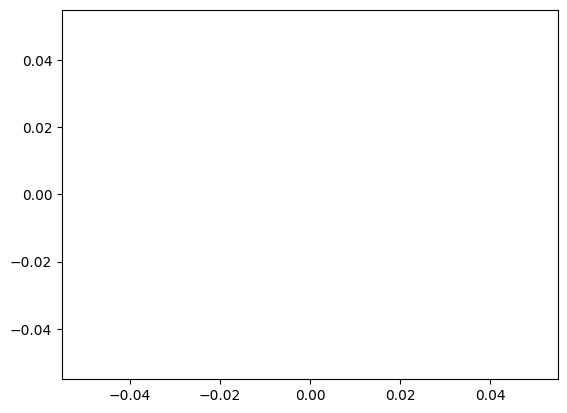

In [11]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)
    
#plt.xticks(range(0,12000,500),rotation=45)
#plt.yticks(range(0,5000,500),rotation=45)
#plt.ylim(0,5000)
plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

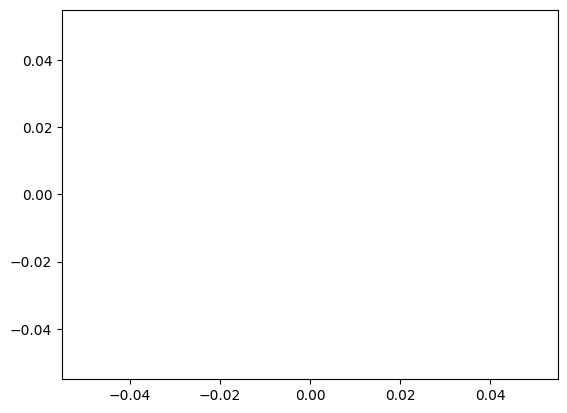

In [12]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

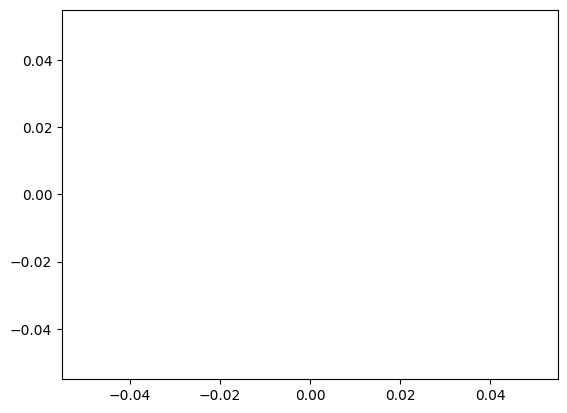

In [6]:
plt.plot(fs02_x_values,fs02_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

2. Linear regression:

Curve adjustment: I need Ncode values and the samples of galons used by the technician. fs0x_dec_value is a vector with Ncodes. I need the galons to do the adjustment and to do it, I must have in mind that technician fill the tank with a recipient of 5 galons, so I will have a vector with the values [5,10,15,..,n]. Other important issue is that TSO do the lineal regression with liters, so in the next cell I will create this vector with the values in liters.


In [9]:
liters_fs=[]
galons_fs=[]
num_galons=int(input('Type tanke volume in galons: '))

for i in range(0,num_galons+5,5):
    galons_fs.append(float(i))
    #print(i)

for i in range(0,len(galons_fs)):
    aux_volume=galons_fs[i]*3.78541
    liters_fs.append(aux_volume)

print(liters_fs)



[0.0, 18.92705, 37.8541, 56.781150000000004, 75.7082, 94.63525, 113.56230000000001, 132.48935, 151.4164, 170.34345000000002, 189.2705, 208.19755, 227.12460000000002, 246.05165000000002, 264.9787, 283.90575, 302.8328, 321.75985000000003, 340.68690000000004, 359.61395, 378.541]


In [11]:
from sklearn.preprocessing import StandardScaler #Estandariza los datos.
from sklearn.linear_model import LinearRegression #Importo el modelo.
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

df_data=pd.read_csv('/home/jlhb1984/py-projects/data/fuel/Libro1.csv',sep=';')
df_data.info()

print(len(liters_fs),len(fs01_dec_value))

df_data['NCode']=df_data['Measured']
df_data['Volume']=df_data['User']

#df_data.to_csv('/home/jlhb1984/py-projects/data/cases/Export.csv')

x=df_data['NCode'].values.reshape(-1, 1)#Si no se pone, sale error porque x_std y y_std requieren este reshape.
y=df_data['Volume'].values.reshape(-1, 1)
sc_x=StandardScaler()
sc_y=StandardScaler()
x_std=sc_x.fit_transform(x)
y_std=sc_y.fit_transform(y)
slr=LinearRegression()
slr.fit(x_std,y_std)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   User         32 non-null     int64 
 1   Measured     32 non-null     int64 
 2   Date         32 non-null     object
 3   Temperature  32 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.1+ KB
21 476


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
X_cols=df_data['NCode'].values.reshape(-1,1)
y_col=df_data['Volume'].values.reshape(-1,1)

X=X_cols
y=y_col

X_train, X_test, y_train, y_test = train_test_split(X,y)
sc_x=StandardScaler().fit(X)
sc_y=StandardScaler().fit(y)

X_train=sc_x.transform(X_train)
X_test=sc_x.transform(X_test)
y_train=sc_y.transform(y_train)
y_test=sc_y.transform(y_test)

model=LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [13]:
model = LinearRegression()
model.fit(X, y)

# 3. Access the Slope and Intercept
slope = model.coef_
intercept = model.intercept_

print(f"Slope (Coefficient): {slope}")
print(f"Intercept: {intercept}")

Slope (Coefficient): [[0.04013901]]
Intercept: [-5.46231156]


Text(0.5, 0, 'N code')

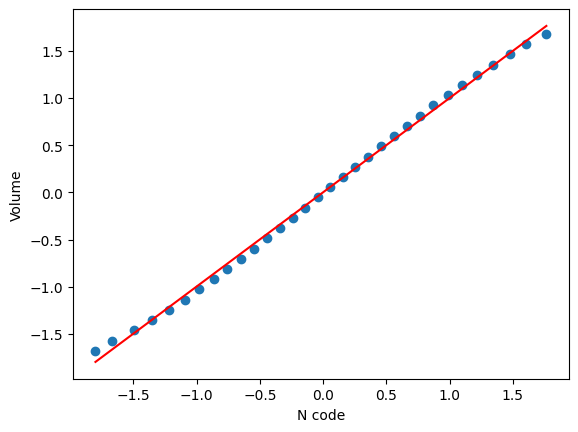

In [14]:
plt.scatter(x_std,y_std)
plt.plot(x_std,slr.predict(x_std),color='red')
plt.ylabel('Volume')
plt.xlabel('N code')

In [15]:
mse = metrics.mean_squared_error(y_test,y_pred)
r2 = metrics.r2_score(y_test, y_pred)

#print("r2 ", r2.round(4))
#print("mse: ", mse.round(4))
print("r2 ", r2)
print("mse: ", mse)

r2  0.994980058975617
mse:  0.0021750624233213556


In [16]:
ncode=input("N Code: ")
num_galons_lr=sc_x.transform(np.array([ncode]).reshape(-1,1))
sc_y.inverse_transform(slr.predict(num_galons_lr))

array([[115.91804775]])